# Movie Data Pipeline Demo

This notebook demonstrates the complete data acquisition and cleaning pipeline for the Rotten Tomatoes and IMDB movie analysis project. We'll use the automated task system to download datasets, clean the data, and scrape additional movie information from Rotten Tomatoes.

## Project Overview

This project analyzes movie reviews and ratings data from Rotten Tomatoes and IMDB.

### Demo Steps

1. **Environment Setup**: Install dependencies and verify setup
2. **Data Download**: Download raw datasets from Kaggle
3. **Data Cleaning**: Clean and validate the downloaded data
4. **Web Scraping**: Scrape additional movie details from Rotten Tomatoes
5. **Data Exploration**: Validate and explore the final cleaned datasets
6. **Methodology**: Demonstrate various analysis methods on the cleaned data
    1. Frequent items
    2. Sentence embeddings
    3. Graph analysis
    4. Collaborative filtering

# Setup task and uv 

Task is a Python library for automating data workflows. uv is a command-line tool for managing and executing these tasks.

Task installation guide can be found at: https://taskfile.dev/installation/

uv installation guide can be found at: https://docs.astral.sh/uv/getting-started/installation/ 

## 1. Environment Setup

First, let's verify that our environment is properly set up and all dependencies are installed.

In [1]:
# Check Python version and environment
import sys
print(f"Python version: {sys.version}")
print(f"Current working directory: {sys.path[0]}")

# Verify required packages are available
try:
    import polars as pl
    import pandas as pd
    import numpy as np
    print("✅ Core data packages available")
except ImportError as e:
    print(f"❌ Missing packages: {e}")

Python version: 3.12.8 (main, Jan 14 2025, 22:49:36) [MSC v.1942 64 bit (AMD64)]
Current working directory: C:\Users\anton\AppData\Roaming\uv\python\cpython-3.12.8-windows-x86_64-none\python312.zip
✅ Core data packages available
✅ Core data packages available


In [2]:
# Sync dependencies using uv
!uv sync

Resolved 156 packages in 2ms
Audited 135 packages in 18ms


## 2. Data Download

Now let's download the raw datasets from Kaggle. This includes the Rotten Tomatoes critic reviews dataset.

In [3]:
# Download datasets from Kaggle
# This will download and save the Rotten Tomatoes datasets locally
!task download-data

task: [sync] uv sync
Resolved 156 packages in 1ms
Audited 135 packages in 15ms
task: [download-data] uv run python src/02807_project/data_loader.py



In [4]:
# Verify downloaded data
from pathlib import Path

data_dir = Path("data/raw")
if data_dir.exists():
    files = list(data_dir.glob("*.csv"))
    print(f"📁 Found {len(files)} CSV files in {data_dir}:")
    for file in files:
        size = file.stat().st_size / 1024 / 1024  # Size in MB
        print(f"   {file.name}: {size:.2f} MB")
else:
    print("❌ Data directory not found")

📁 Found 4 CSV files in data\raw:
   actorfilms.csv: 11.81 MB
   large_movie_dataset.csv: 1561.56 MB
   rotten_tomatoes_critic_reviews.csv: 231.74 MB
   rotten_tomatoes_movie_details.csv: 6.27 MB


## 3. Data Cleaning

Next, let's clean the downloaded data by removing null values, invalid ratings, and standardizing the format.

In [5]:
# Clean the downloaded datasets
# This removes nulls, invalid ratings, and maps review scores to numeric values
!task clean-data

2025-12-01 10:30:48 | INFO | __main__:<module>:297 - 🚀 Starting data cleaning process...
2025-12-01 10:30:48 | INFO | __main__:clean_large_movie_dataset:112 - 🧹 Cleaning Large Movie Dataset...
2025-12-01 10:31:07 | INFO | __main__:clean_large_movie_dataset:158 - ✅ Saved cleaned dataset to data\clean\large_movie_dataset_clean.csv
2025-12-01 10:31:07 | INFO | __main__:clean_rotten_tomatoes_dataset:163 - 🧹 Cleaning Rotten Tomatoes Dataset...
2025-12-01 10:31:08 | INFO | __main__:clean_rotten_tomatoes_dataset:202 - ✅ Saved cleaned dataset to data\clean\rotten_tomatoes_critic_reviews_clean.csv
2025-12-01 10:31:08 | INFO | __main__:clean_rotten_tomatoes_movie_details:207 - 🧹 Cleaning Rotten Tomatoes Movie Details...
2025-12-01 10:31:08 | INFO | __main__:clean_rotten_tomatoes_movie_details:253 - ✅ Saved cleaned movie details to data\clean\rotten_tomatoes_movie_details_clean.csv
2025-12-01 10:31:08 | INFO | __main__:clean_actorfilms_dataset:258 - 🧹 Cleaning Actor Films Dataset...
2025-12-01 10

task: [clean-data] uv run python src/02807_project/data_cleaner.py



In [6]:
# Quick exploration of cleaned data
cleaned_files = list(Path("data/clean").glob("*.csv"))
if cleaned_files:
    print(f"📁 Cleaned datasets available:")
    for file in cleaned_files:
        df = pl.read_csv(file)
        print(f"\n📊 {file.name}:")
        print(f"   Rows: {len(df):,}")
        print(f"   Columns: {len(df.columns)}")
        print(f"   Columns: {', '.join(df.columns)}")
else:
    print("❌ No cleaned data files found")

📁 Cleaned datasets available:

📊 actorfilms_clean.csv:
   Rows: 191,873
   Columns: 7
   Columns: Actor, ActorID, Film, Year, Votes, Rating, FilmID

📊 large_movie_dataset_clean.csv:
   Rows: 25,000,095
   Columns: 7
   Columns: , User_Id, Movie_Name, Rating, Genre, Release_Year, Movie_Name_Normalized

📊 rotten_tomatoes_critic_reviews_clean.csv:
   Rows: 121,877
   Columns: 9
   Columns: rotten_tomatoes_link, critic_name, top_critic, publisher_name, review_type, review_score, review_date, review_content, review_score_numeric

📊 rotten_tomatoes_movie_details_clean.csv:
   Rows: 17,661
   Columns: 4
   Columns: rotten_tomatoes_link, title, description, release_year

📊 large_movie_dataset_clean.csv:
   Rows: 25,000,095
   Columns: 7
   Columns: , User_Id, Movie_Name, Rating, Genre, Release_Year, Movie_Name_Normalized

📊 rotten_tomatoes_critic_reviews_clean.csv:
   Rows: 121,877
   Columns: 9
   Columns: rotten_tomatoes_link, critic_name, top_critic, publisher_name, review_type, review_scor

## 4. Web Scraping - Rotten Tomatoes Data

## SKIPPED CELL (Takes too long to run, data is in git repo)

Now let's scrape additional movie details (titles, descriptions, release years) from Rotten Tomatoes using the movie IDs from our cleaned dataset.

In [7]:
# # Scrape movie details from Rotten Tomatoes
# # This will scrape titles, descriptions, and release years for movies in our dataset
# # Note: This may take several minutes depending on the number of movies
# !task scrape-rt-movies

# # Check for failed scrapes and retry them
# # This will only re-scrape movies that failed in the previous attempt
# # Note: Run this only if you suspect some scrapes failed
# !task retry-failed-scrapes

## 5. Final Data Exploration

Let's explore our complete dataset including the scraped Rotten Tomatoes data.

In [8]:
# Explore all datasets (raw and cleaned)
# This provides comprehensive statistics and summaries
!task explore-data

2025-12-01 10:31:23 | INFO | __main__:explore_dataset:12 - === Exploring Large Movie Dataset (Raw) ===
2025-12-01 10:31:24 | INFO | __main__:explore_dataset:80 - 📊 Dataset size: 25,000,095 total rows
2025-12-01 10:31:24 | INFO | __main__:explore_dataset:81 - 🔍 Sample size: 1000 rows x 5 columns
2025-12-01 10:31:24 | INFO | __main__:explore_dataset:82 - Basic statistics:
2025-12-01 10:31:24 | INFO | __main__:explore_dataset:83 - shape: (9, 6)
┌────────────┬────────────┬──────────┬───────────────────────┬──────────┬────────────────────┐
│ statistic  ┆            ┆ User_Id  ┆ Movie_Name            ┆ Rating   ┆ Genre              │
│ ---        ┆ ---        ┆ ---      ┆ ---                   ┆ ---      ┆ ---                │
│ str        ┆ f64        ┆ f64      ┆ str                   ┆ f64      ┆ str                │
╞════════════╪════════════╪══════════╪═══════════════════════╪══════════╪════════════════════╡
│ count      ┆ 1000.0     ┆ 1000.0   ┆ 1000                  ┆ 1000.0   ┆ 1000 

task: [explore-data] uv run python src/02807_project/explore_data.py --version both



# 5.5 Merge data

In [9]:
# Merge cleaned datasets into a single file
!task merge-data

2025-12-01 10:31:29 | INFO | __main__:merge_all_datasets:241 - 🚀 Starting dataset merge process...
2025-12-01 10:31:29 | INFO | __main__:merge_rotten_tomatoes_data:76 - 🔗 Merging Rotten Tomatoes datasets...
2025-12-01 10:31:29 | INFO | __main__:merge_rotten_tomatoes_data:136 - ✅ Merged Rotten Tomatoes data: 17661 movies with 121877 total reviews
2025-12-01 10:31:29 | INFO | __main__:prepare_large_movie_dataset:148 - 📊 Preparing Large Movie Dataset...
2025-12-01 10:31:47 | INFO | __main__:prepare_large_movie_dataset:184 - ✅ Prepared Large Movie Dataset: 54888 unique movies from 25000095 ratings
2025-12-01 10:31:48 | INFO | __main__:prepare_actorfilms_dataset:196 - 🎬 Preparing Actor Films Dataset...
2025-12-01 10:31:50 | INFO | __main__:prepare_actorfilms_dataset:234 - ✅ Prepared Actor Films Dataset: 40973 unique films from 191873 actor-film records
2025-12-01 10:31:50 | INFO | __main__:merge_all_datasets:261 - 📋 Datasets available for merge: Rotten Tomatoes, Large Movie Dataset, Actor F

task: [merge-data] uv run python src/02807_project/merge_datasets.py



In [10]:
# Quick exploration of merged data
merged_files = list(Path("data/merged").glob("*.csv"))
if merged_files:
    print(f"📁 Merged datasets available:")
    for file in merged_files:
        df = pl.read_csv(file)
        print(f"\n📊 {file.name}:")
        print(f"   Rows: {len(df):,}")
        print(f"   Columns: {len(df.columns)}")
        print(f"   Columns: {', '.join(df.columns)}")
else:
    print("❌ No merged data files found")

📁 Merged datasets available:


📁 Merged datasets available:



📊 movies_merged.csv:
   Rows: 74,853
   Columns: 29
   Columns: title_normalized, movie_title, release_year, rotten_tomatoes_link, title, description, rt_critics_list, rt_publishers_list, rt_reviews_list, rt_avg_review_score, rt_review_scores_list, rt_top_critic_count, rt_review_count, rt_release_year, lm_movie_name_original, lm_avg_rating, lm_ratings_list, lm_user_ids_list, lm_genre, lm_release_year, lm_rating_count, af_film_original, af_actors_list, af_actor_ids_list, af_year, af_rating, af_votes, af_film_id, af_actor_count


### Available Data Files

After running this pipeline, you'll have:

- `data/raw/rotten_tomatoes_movies.csv` - Raw movie data from Kaggle
- `data/raw/rotten_tomatoes_critic_reviews.csv` - Raw critic reviews from Kaggle
- `data/clean/rotten_tomatoes_movies_clean.csv` - Cleaned movie data
- `data/clean/rotten_tomatoes_critic_reviews_clean.csv` - Cleaned critic reviews
- `data/raw/rotten_tomatoes_movie_details.csv` - Scraped movie details (titles, descriptions, years)

### Quick Pipeline Command

For future runs, you can use the complete pipeline in one command:
```bash
task setup-data
```

This runs: sync → download-data → clean-data all in sequence.

# 6 Methods

## 6.1 Frequent items

In [ ]:
# Runs frequent items analysis with min_support of 0.1 and min_confidence of 0.8
# Adjust these parameters as needed for futher analysis - may take significantly longer time with lower thresholds
!task run-frequent-items -- --min-support 0.1 --min-confidence 0.8

## 6.2 Sentence embeddings

## 6.3 Graph analysis

The graph anlysis is demonstrated in the `analyze_actor_network.py` script. You can run it on a subset of the data for quick testing:

```bash
task run-graph-analysis-subset
```

However for the full analysis, run:

```bash
task analyze-actor-network
```

This does take a while to run on the full dataset.

In [ ]:
# Run graph analysis on a subset of data for quick demo
# This analyzes movie networks based on shared actors using community detection methods
!task run-graph-analysis-subset # The subset is 5000 nodes

# !task analyze-actor-network

2025-12-01 10:46:06 | INFO | __main__:main:1050 - 🚀 Starting actor network analysis...
2025-12-01 10:46:06 | INFO | __main__:load_actor_film_data:53 - 📊 Loading actor-film data...
2025-12-01 10:46:06 | INFO | __main__:load_actor_film_data:103 -    Subset to 5000 films: 22739 actor-film relationships
2025-12-01 10:46:06 | INFO | __main__:main:1054 -    Loaded 22739 actor-film relationships
2025-12-01 10:46:06 | INFO | __main__:build_movie_coactor_graph:118 - 🔨 Building movie co-actor graph...
2025-12-01 10:46:06 | INFO | __main__:build_movie_coactor_graph:128 -    Found 7014 unique actors
2025-12-01 10:46:06 | INFO | __main__:build_movie_coactor_graph:147 -    Found 52167 movie pairs with shared actors
2025-12-01 10:46:06 | INFO | __main__:build_movie_coactor_graph:154 - ✅ Graph constructed: 4866 nodes, 52167 edges
2025-12-01 10:46:06 | INFO | __main__:apply_girvan_newman:175 - 🔍 Applying Girvan-Newman method (target: 10 communities)...
2025-12-01 10:46:07 | INFO | __main__:apply_girvan

task: [run-graph-analysis-subset] uv run python src/02807_project/analyze_actor_network.py --subset-size 5000



📁 Generated analysis files:

🖼️  Visualization plots (7 files):
   communities_fast_spectral_clustering.png


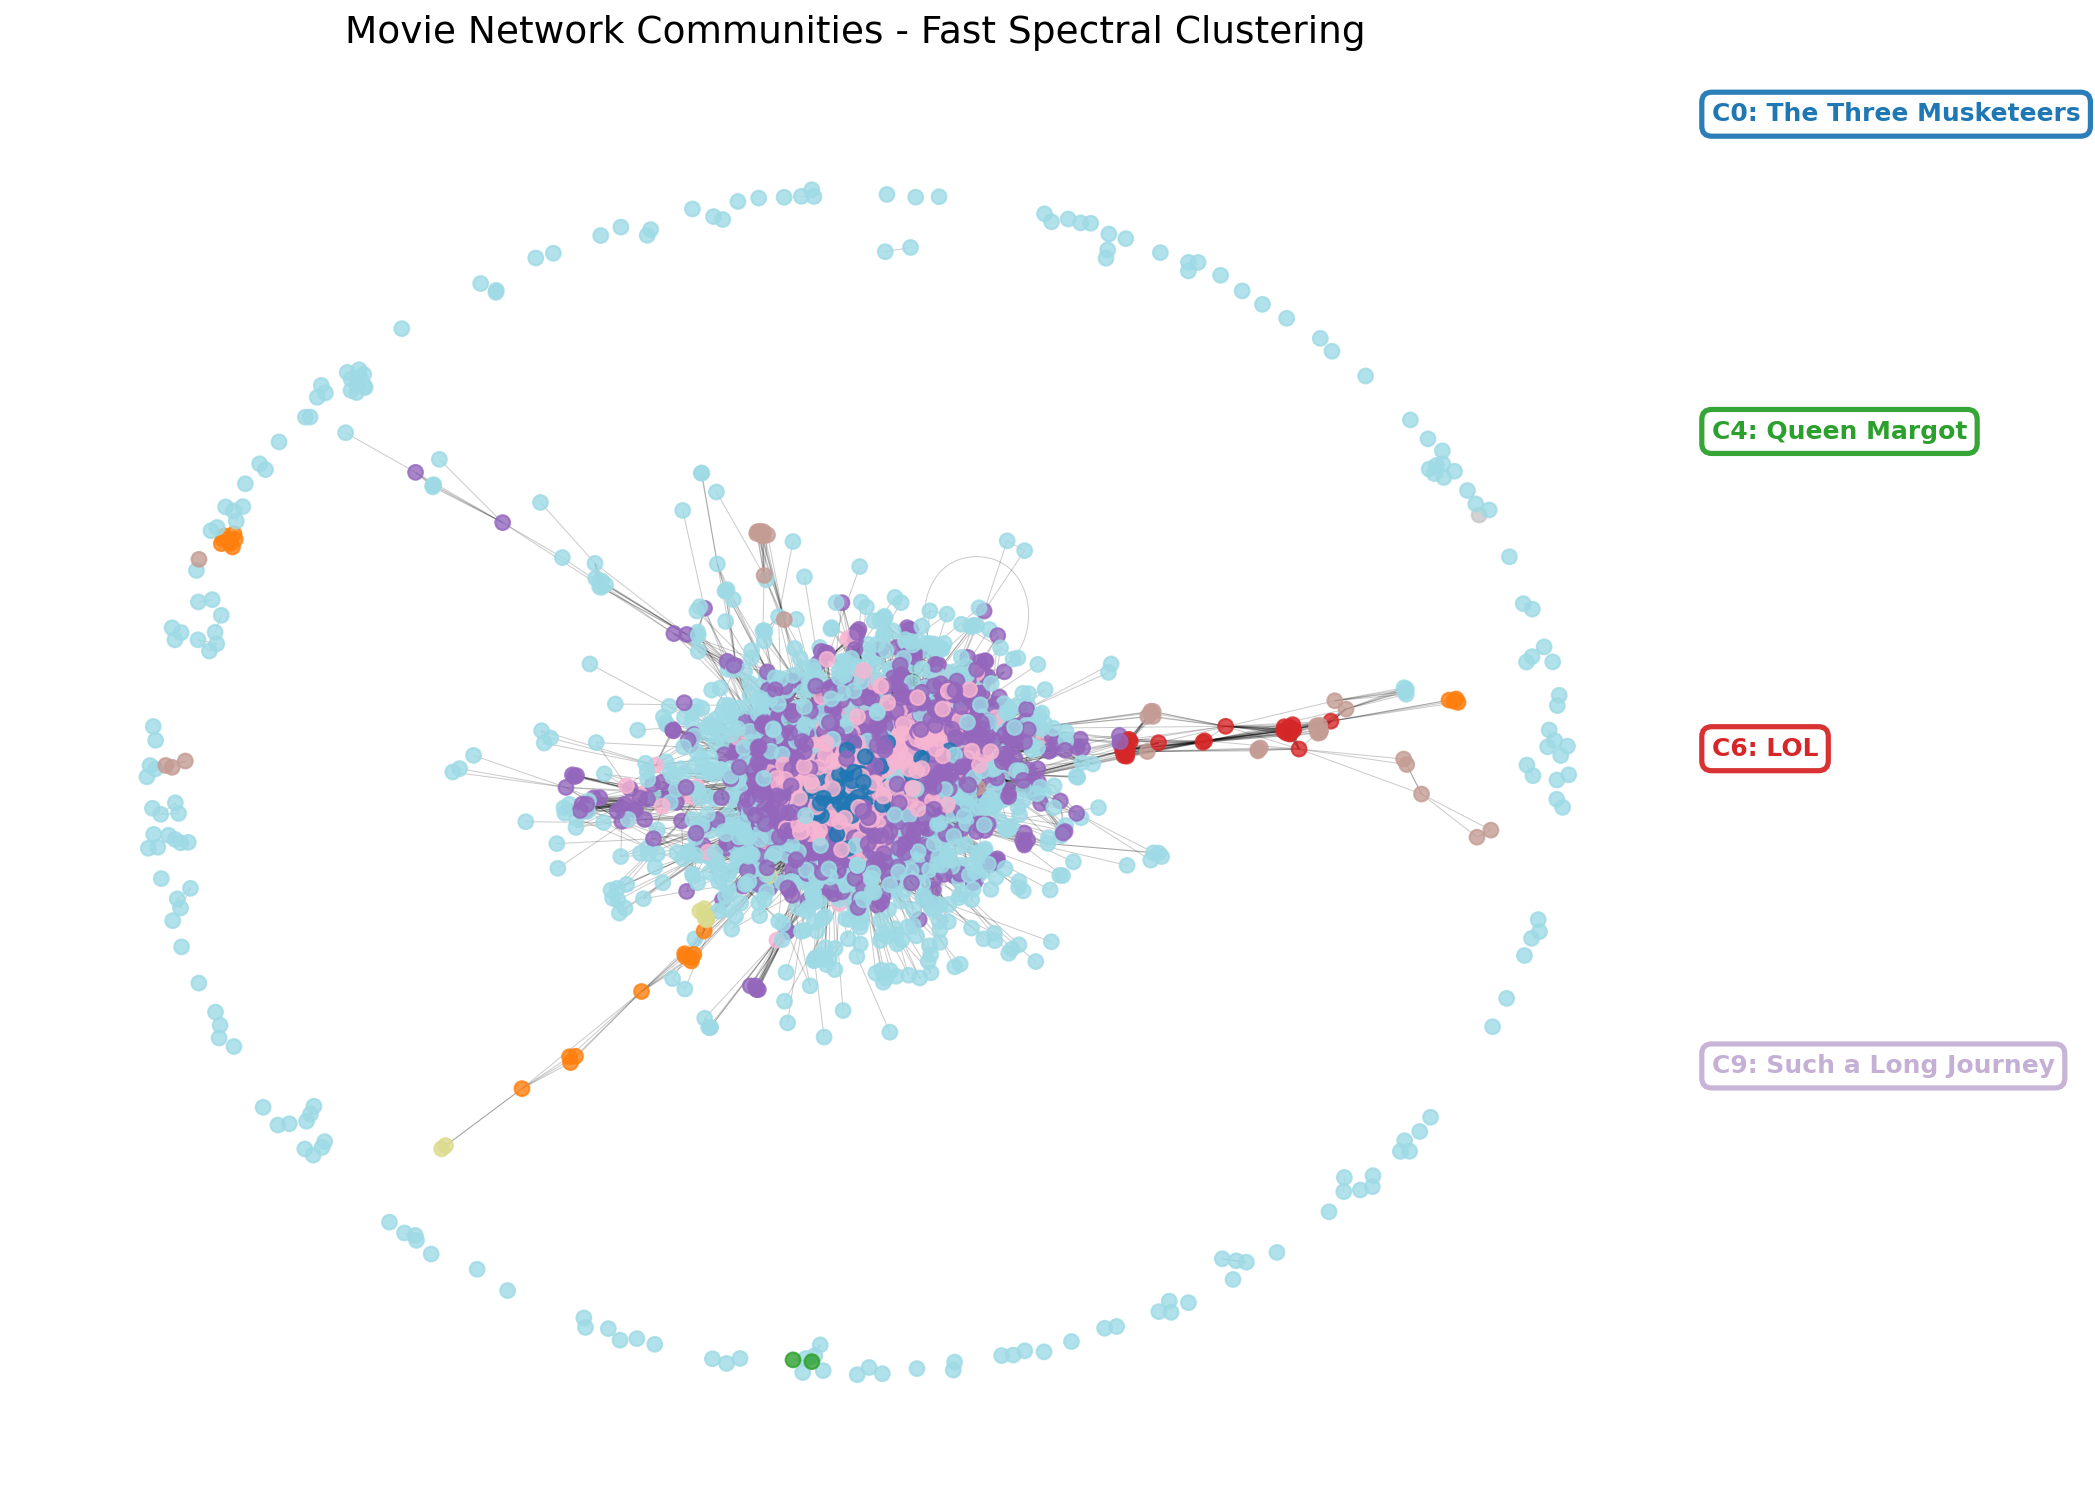

   communities_girvan-newman.png


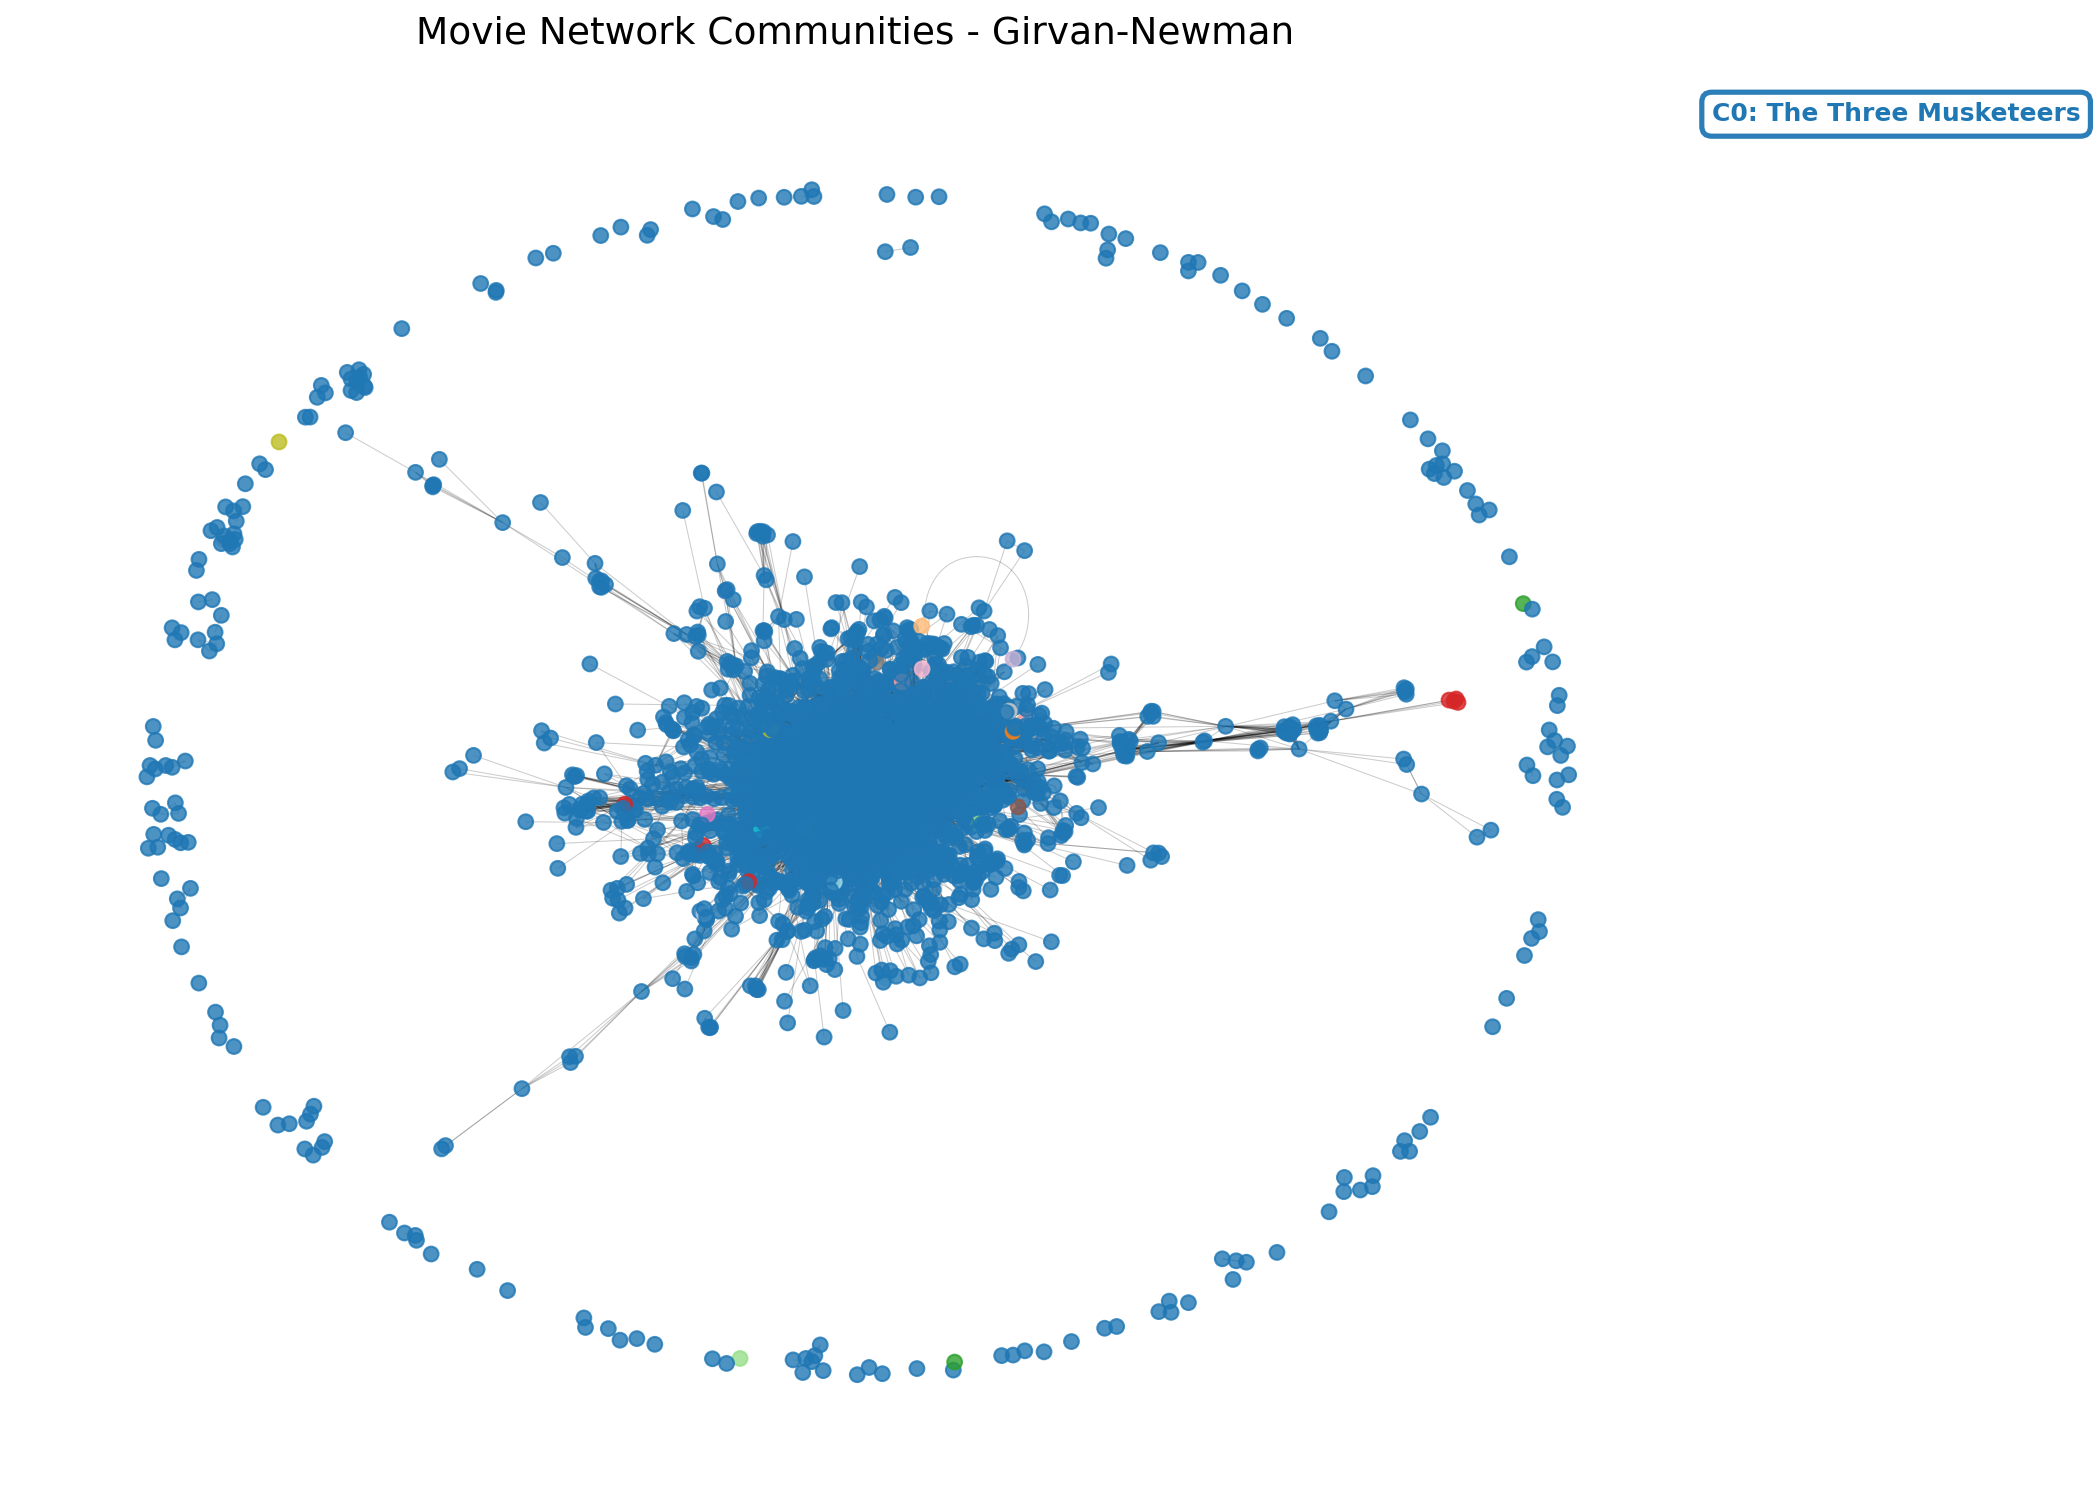

   communities_louvain.png


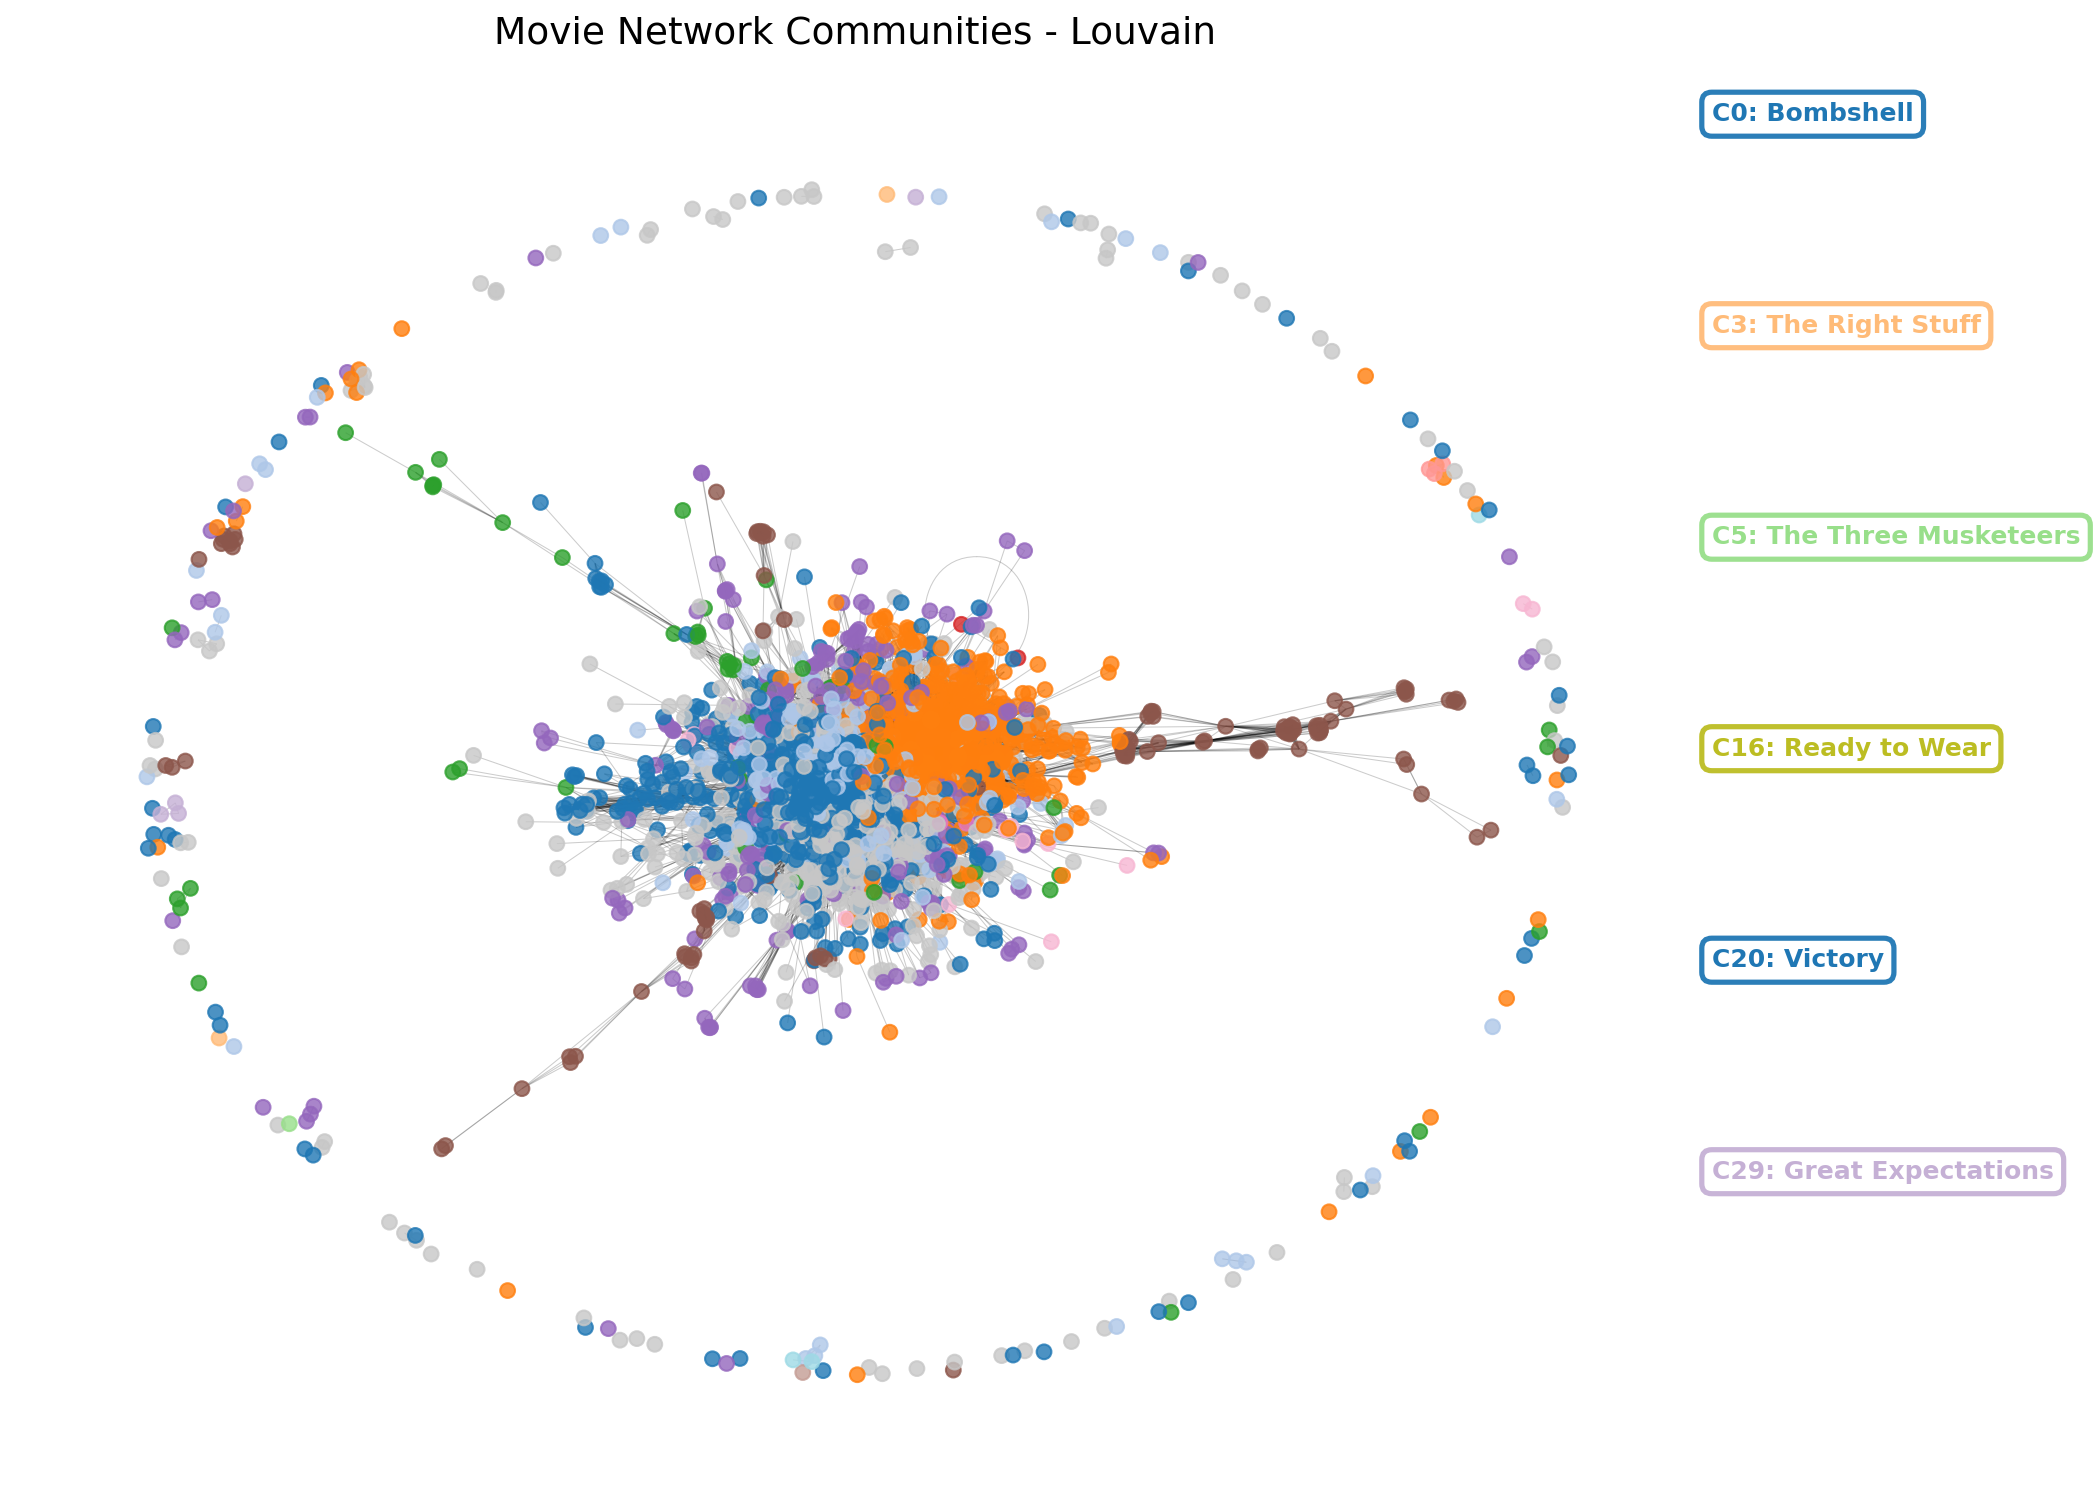

   network_graph.png


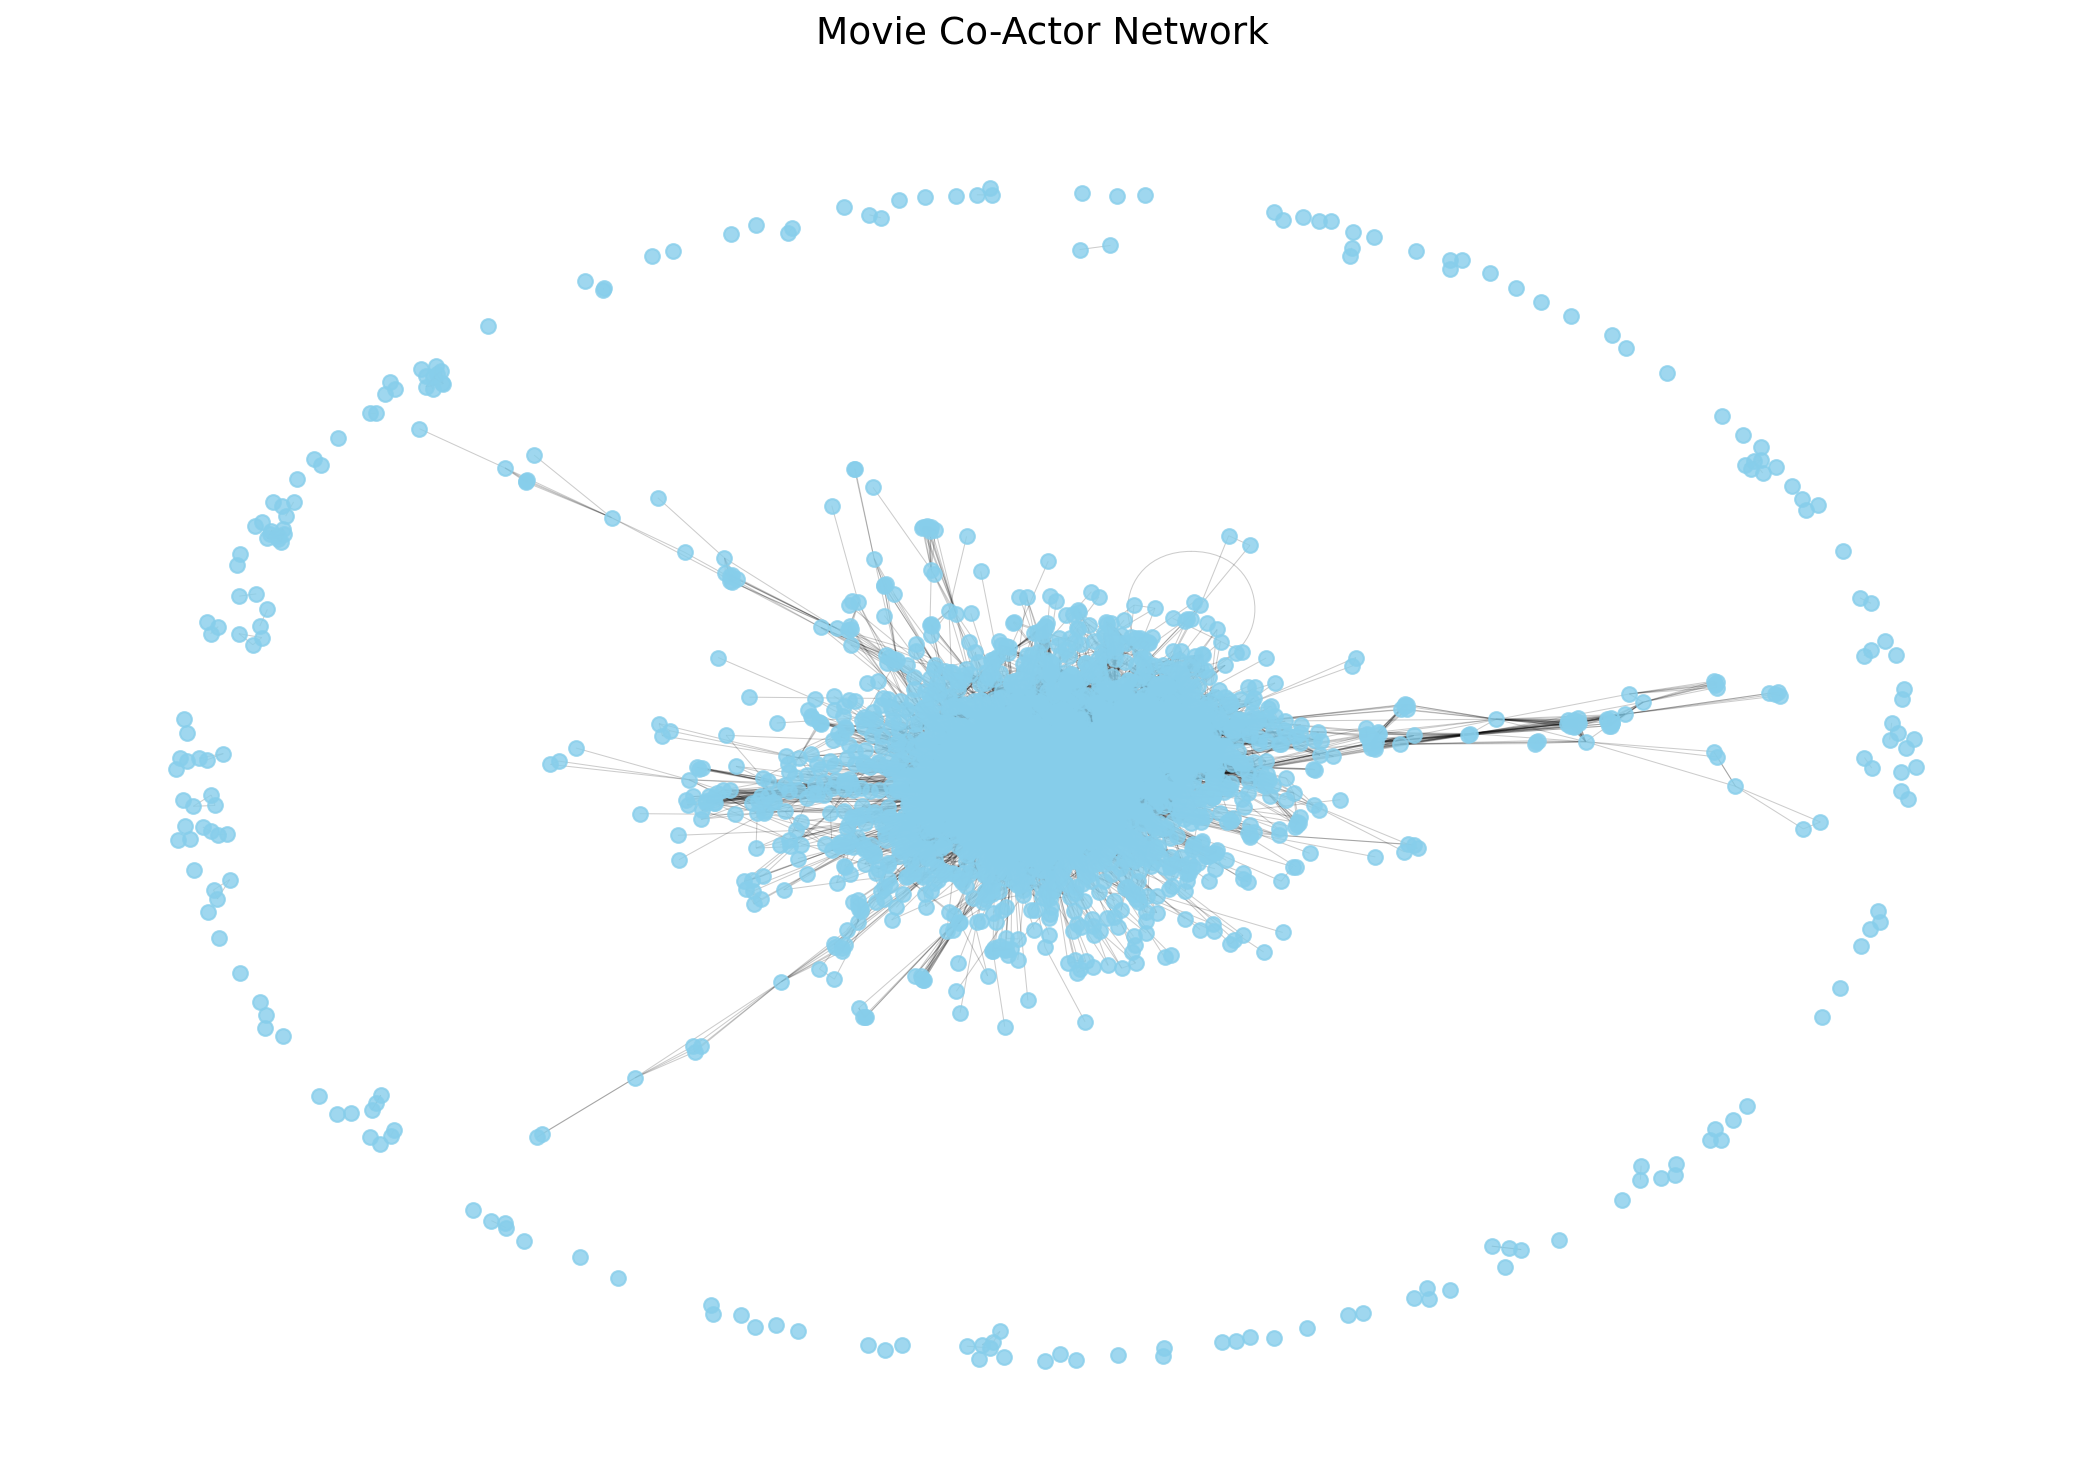

   top_movies_fast_spectral_clustering.png


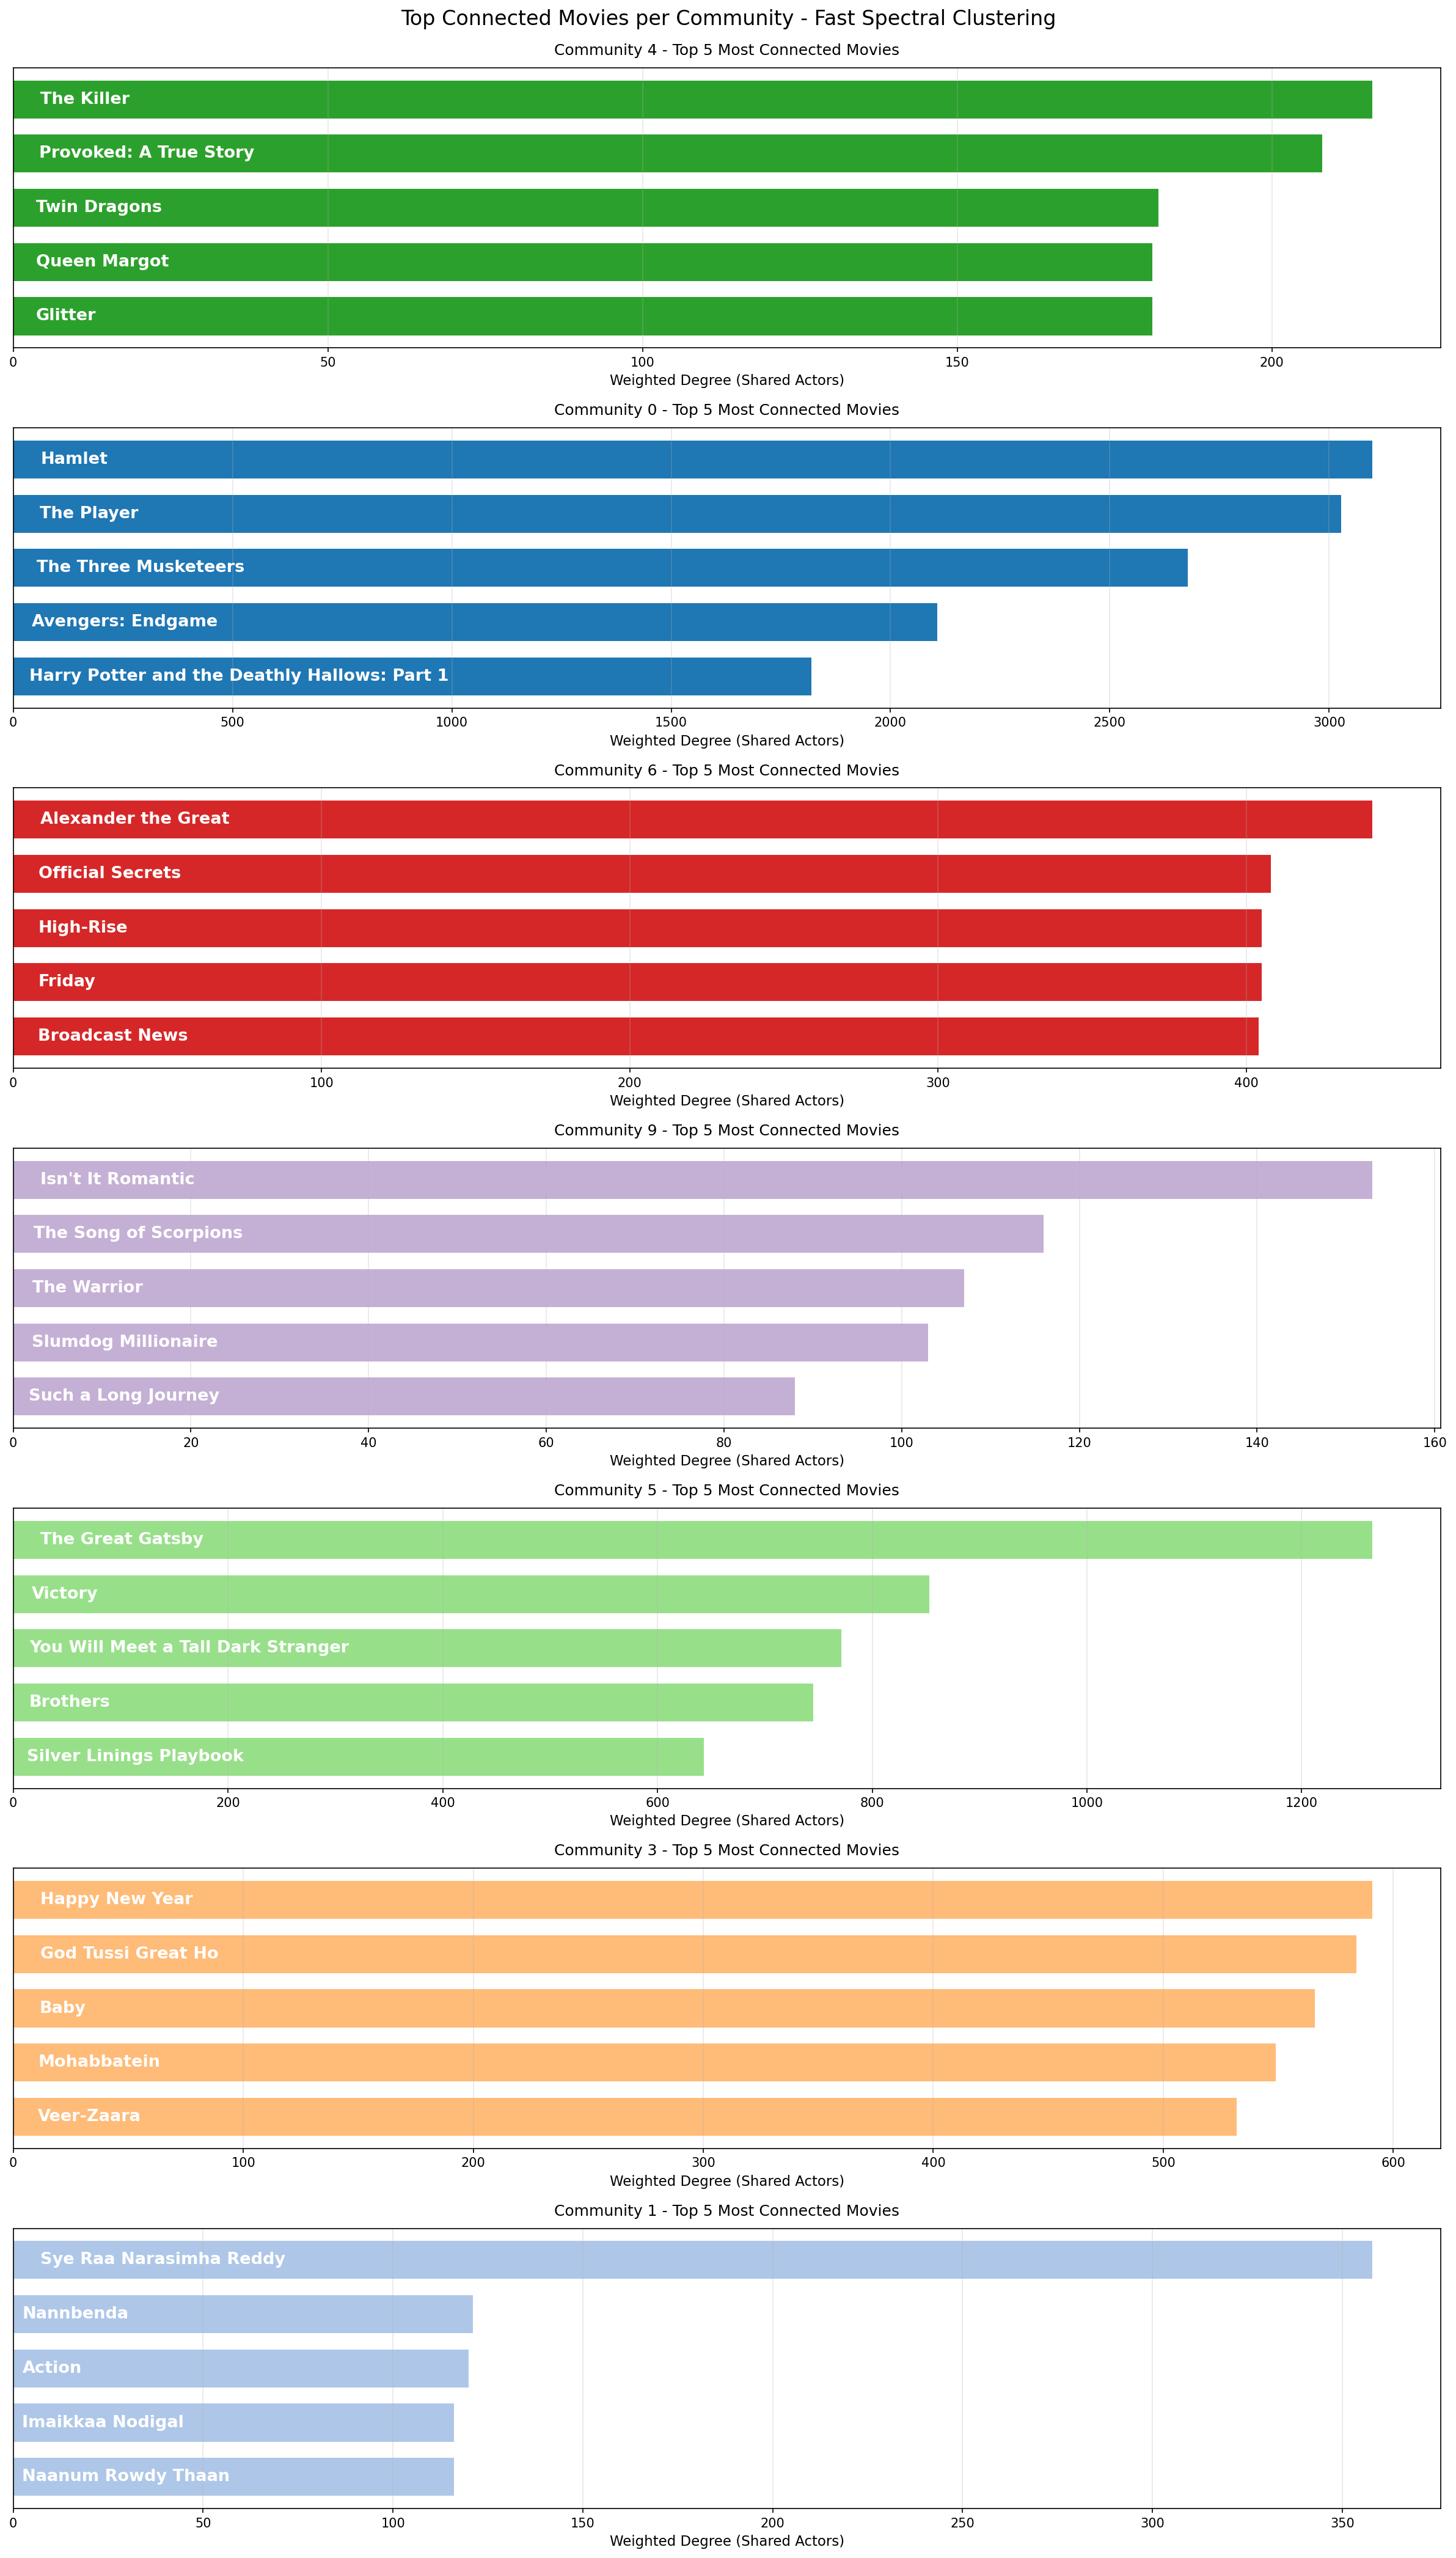

   top_movies_girvan-newman.png


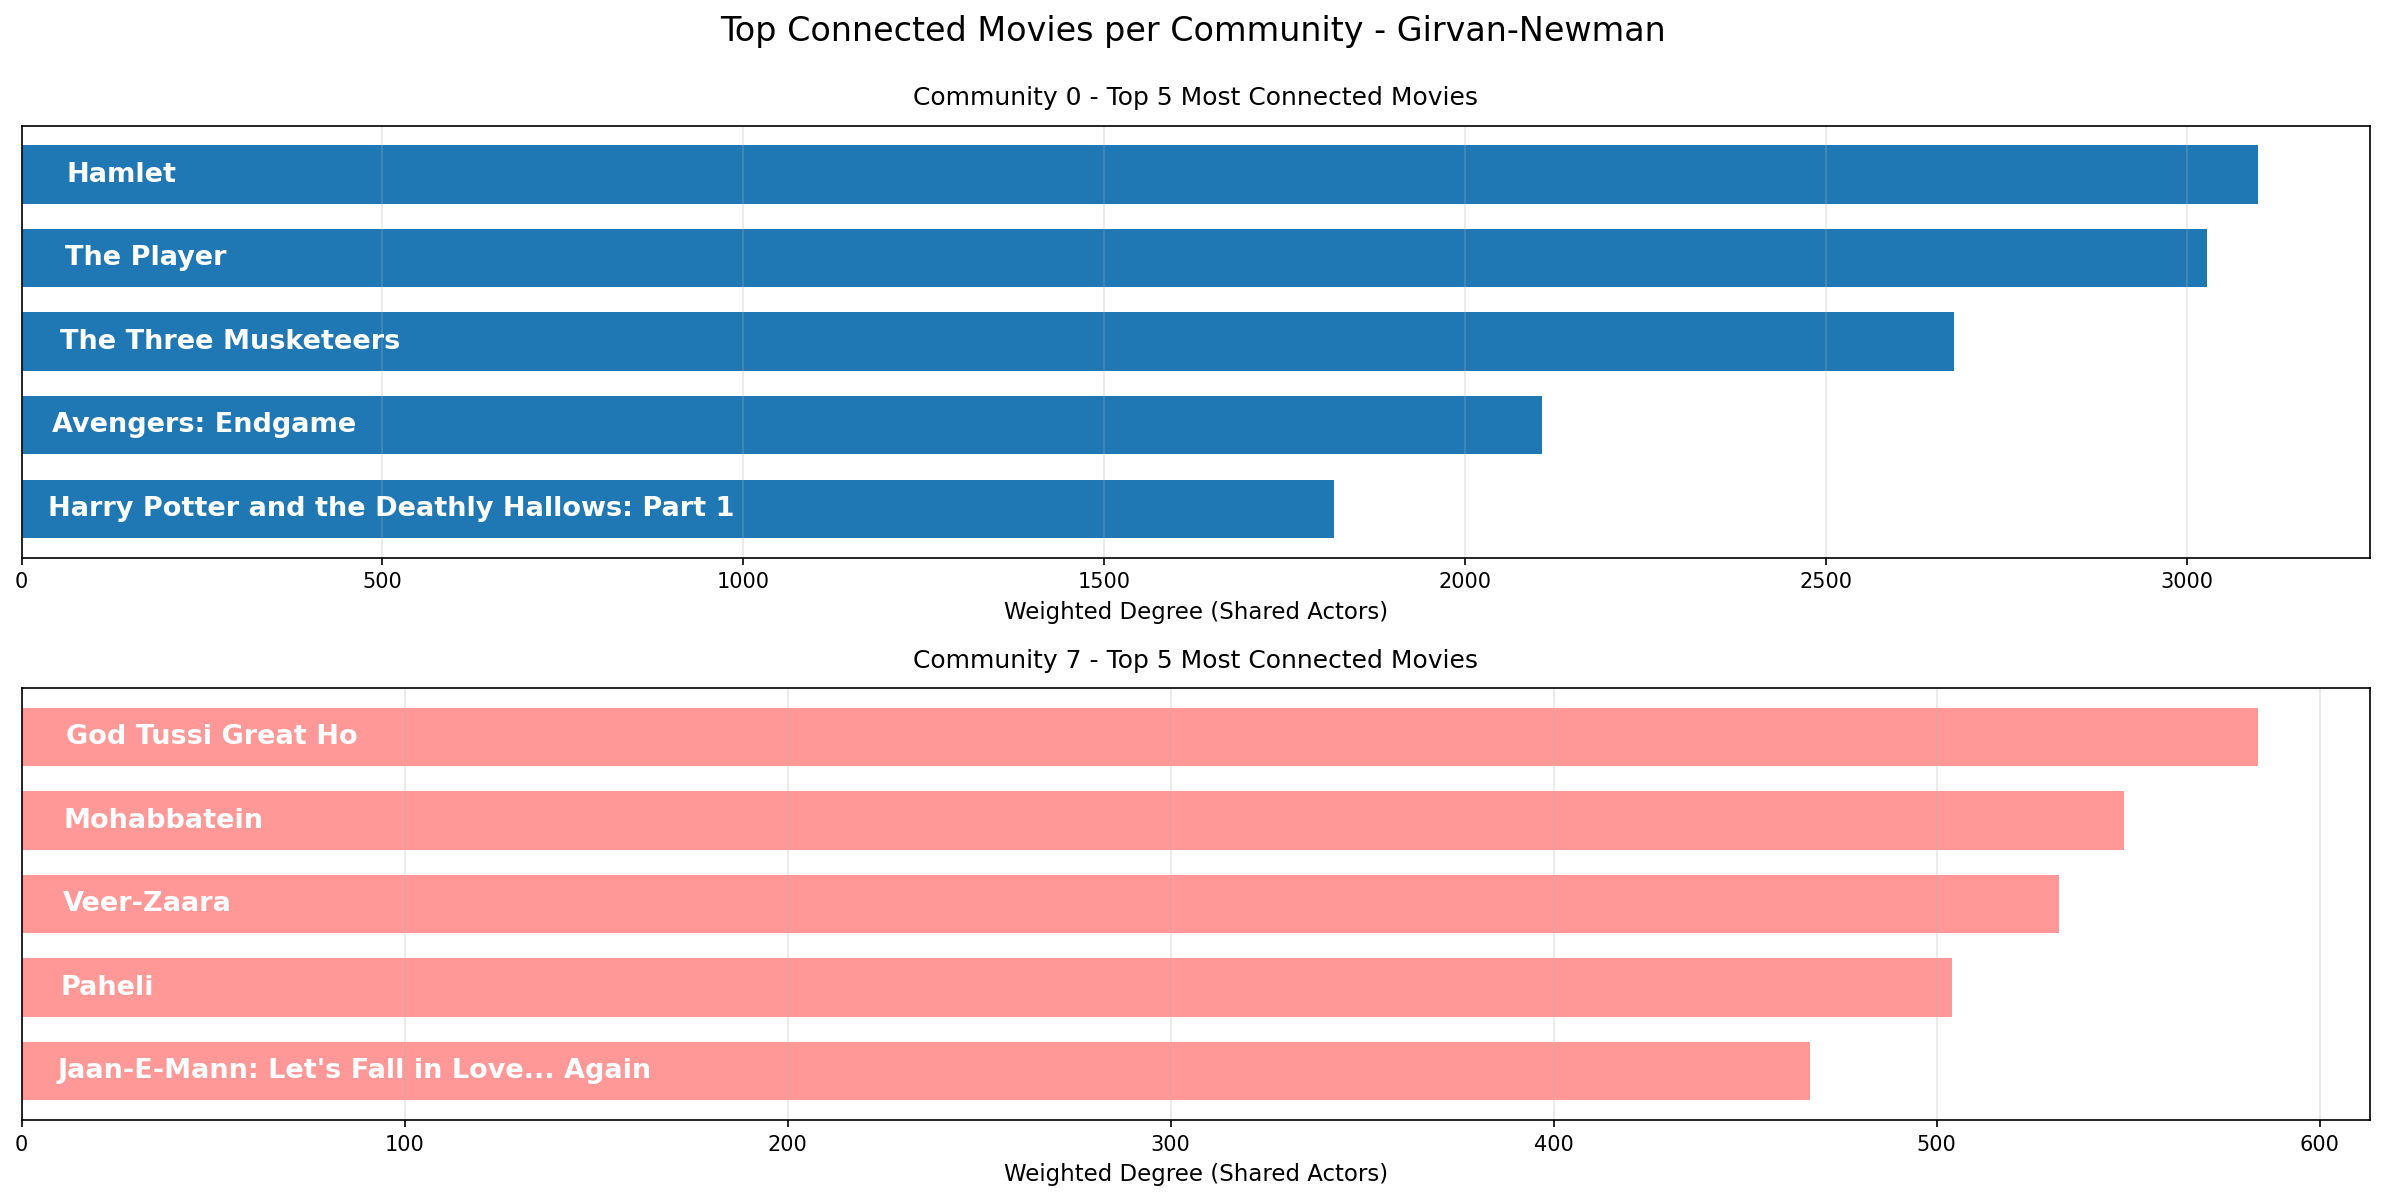

   top_movies_louvain.png


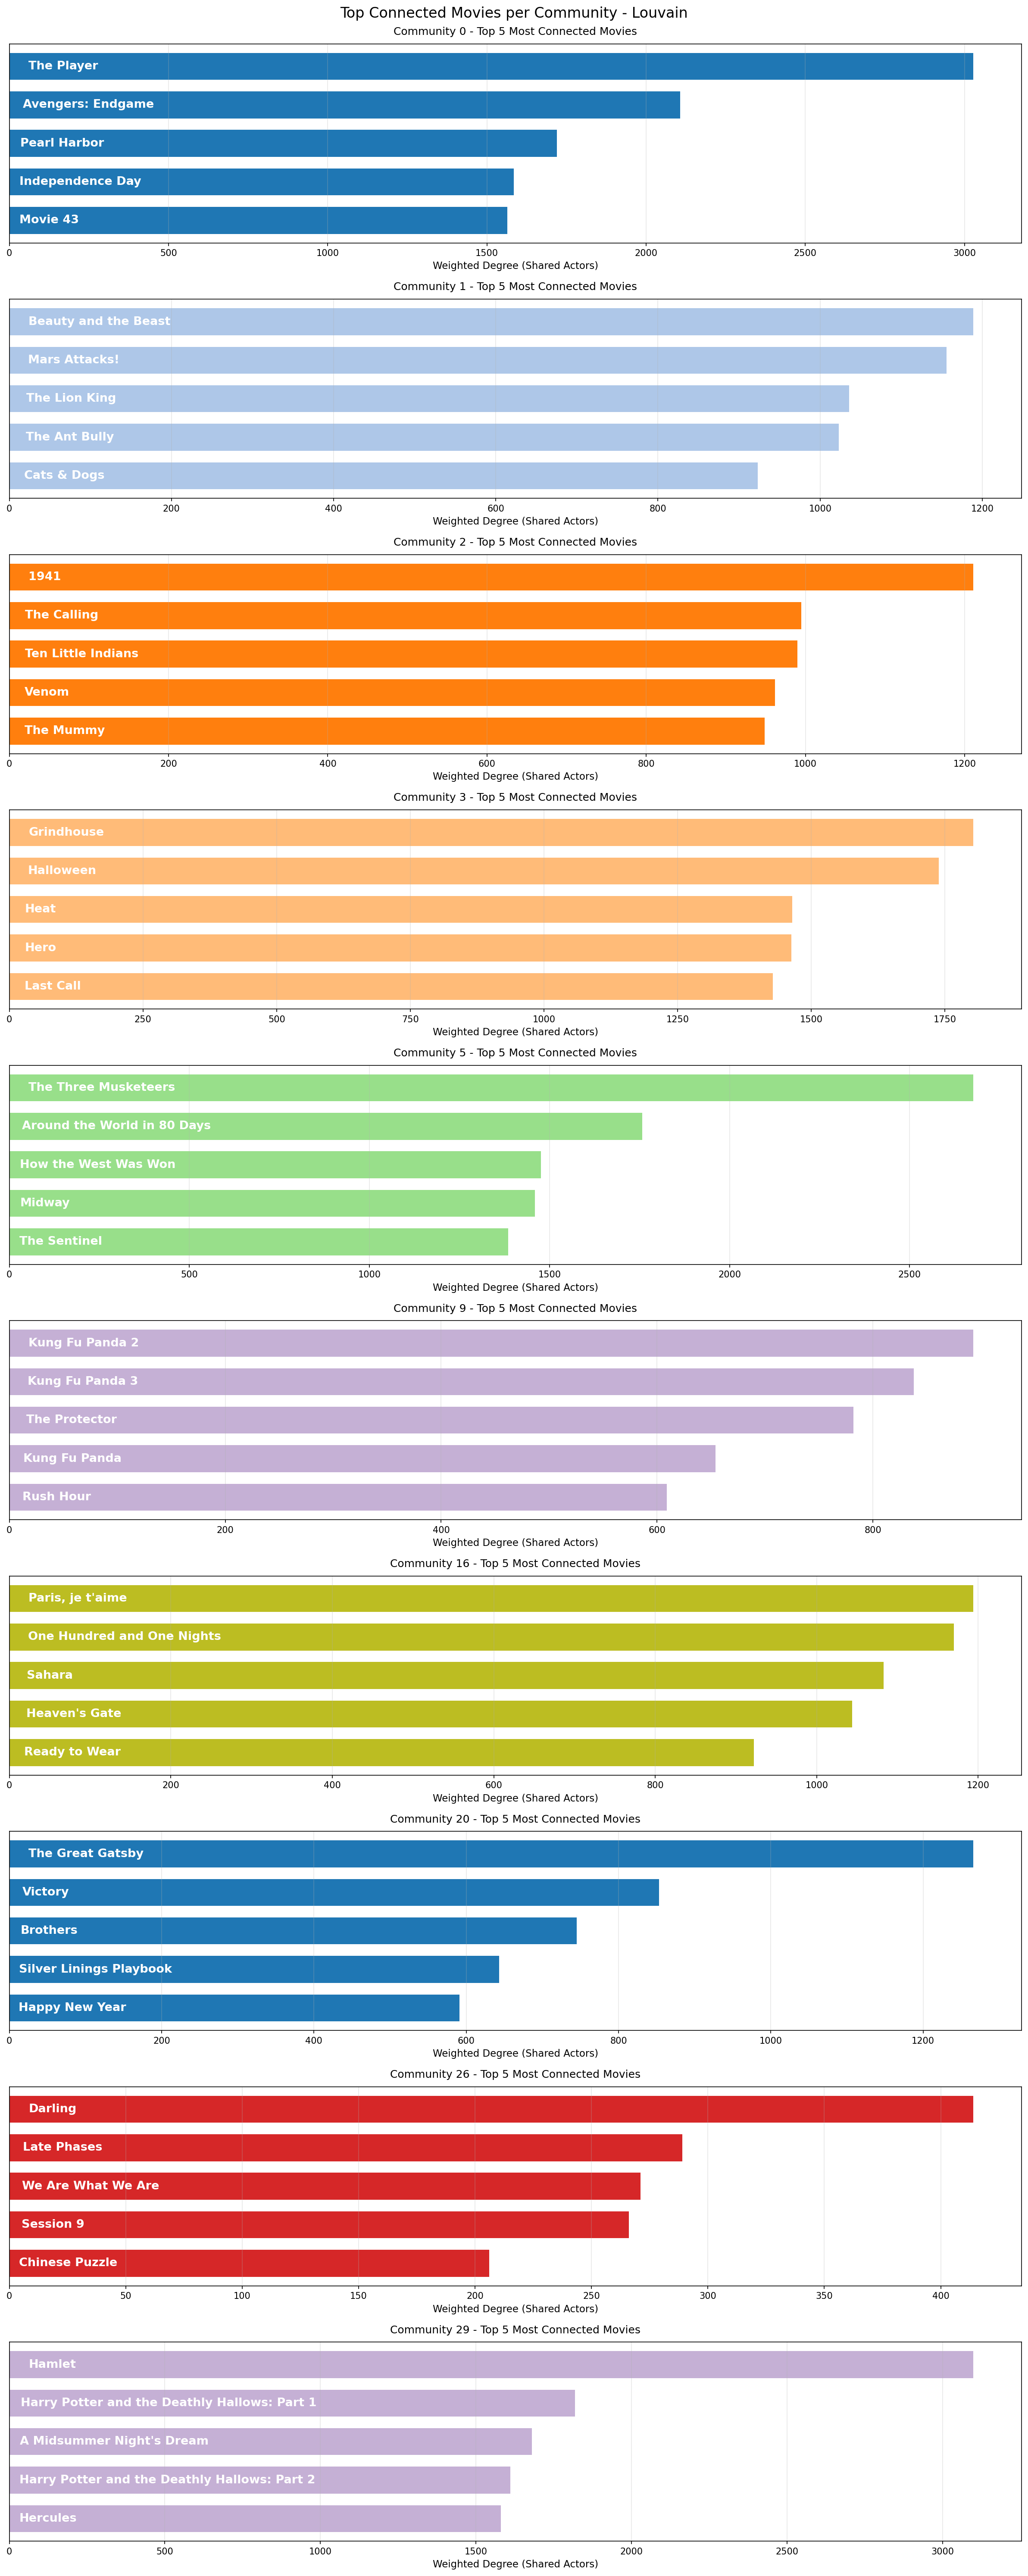


📊 Analysis data (4 files):
   community_assignments.json
   community_statistics.json


### Community Detection Results

**Girvan-Newman**: 210 communities, Modularity: 0.0323, Largest community: 39824 movies

**Louvain**: 43 communities, Modularity: 0.4079, Largest community: 13145 movies

**Fast Spectral Clustering**: 76 communities, Modularity: 0.0836, Largest community: 13365 movies

...

### Null Model Comparison

**Girvan-Newman**: Null model: 0.0000 ± 0.0000 (10 models)

**Louvain**: Null model: -0.0000 ± 0.0002 (10 models)

**Fast Spectral Clustering**: Null model: 0.0000 ± 0.0004 (10 models)

   top_movies_per_community.json

🔗 Graph files (1 files):
   movie_coactor_graph.gexf (4857330 bytes)


In [5]:
# Show the generated plots and files

from pathlib import Path
from IPython.display import Image, display, Markdown
import json

analysis_dir = Path("data/analysis")

if analysis_dir.exists():
    print("📁 Generated analysis files:")

    # Show visualization images
    image_files = list(analysis_dir.glob("*.png"))
    if image_files:
        image_files = [img_file for img_file in image_files if img_file.name != "similarity_heatmap.png"]
        print(f"\n🖼️  Visualization plots ({len(image_files)} files):")
        for img_file in sorted(image_files):
            print(f"   {img_file.name}")
            display(Image(filename=str(img_file), width=800))

    # Show JSON data files
    json_files = list(analysis_dir.glob("*.json"))
    if json_files:
        print(f"\n📊 Analysis data ({len(json_files)} files):")
        for json_file in sorted(json_files):
            print(f"   {json_file.name}")

            # Display community statistics in a nice format
            if "statistics" in json_file.name:
                try:
                    with open(json_file, 'r') as f:
                        data = json.load(f)

                    if "community_statistics" in json_file.name:
                        display(Markdown("### Community Detection Results"))
                        for stat in data:
                            display(Markdown(f"**{stat['method']}**: {stat['num_communities']} communities, "
                                           f"Modularity: {stat['modularity']:.4f}, "
                                           f"Largest community: {stat['largest_community']} movies"))
                    elif "null_model_statistics" in json_file.name:
                        display(Markdown("### Null Model Comparison"))
                        for stat in data:
                            display(Markdown(f"**{stat['method']}**: "
                                           f"Null model: {stat['mean_modularity']:.4f} ± {stat['std_modularity']:.4f} "
                                           f"({stat['num_models']} models)"))
                except Exception as e:
                    print(f"   Could not display {json_file.name}: {e}")

    # Show graph file
    graph_files = list(analysis_dir.glob("*.gexf"))
    if graph_files:
        print(f"\n🔗 Graph files ({len(graph_files)} files):")
        for g_file in graph_files:
            print(f"   {g_file.name} ({g_file.stat().st_size} bytes)")

else:
    print("❌ Analysis directory not found. Run the graph analysis first.")

## 6.4 Collaborative filtering

The collaborative filtering analysis is demonstrated in the `visualize_similarities.py` script.

```bash
task run-visualize-similarities
```
(The above takes about 8-9 minutes to run).

If you want to run the full analysis with test and train, use:

```bash
task run-collaborative-filtering
```

In [ ]:
!task run-visualize-similarities -- --n-movies 15 --min-common-users 100

# # Runs collaborative filterings with ...
# !task run-collaborative-filtering

2025-12-01 12:56:14 | INFO | __main__:main:182 - Loading ratings data...
2025-12-01 12:56:20 | INFO | collaborative_filtering:load_ratings_data:50 - Filtering movies with rating >= 0.0: removed 0.0% of ratings
2025-12-01 12:56:51 | INFO | collaborative_filtering:load_ratings_data:72 - Loaded 24899017 ratings from 162541 users for 54888 movies
2025-12-01 12:56:51 | INFO | __main__:main:186 - Computing item similarities...
2025-12-01 12:56:56 | INFO | collaborative_filtering:compute_item_similarity:156 - Computing similarity for 54888 movies
2025-12-01 12:56:56 | INFO | collaborative_filtering:compute_item_similarity:158 - Constructing sparse user-item matrix...
2025-12-01 12:57:39 | INFO | collaborative_filtering:compute_item_similarity:186 - Sparse matrix shape: (162541, 54888), stored elements: 24899017
2025-12-01 12:57:39 | INFO | collaborative_filtering:compute_item_similarity:188 - Computing item-item similarity using sparse matrix operations...
2025-12-01 13:01:18 | INFO | collabo

task: [run-visualize-similarities] uv run python src/02807_project/visualize_similarities.py --n-movies 50 --min-common-users 100




🖼️  Visualization plots (1 files):
   similarity_heatmap.png


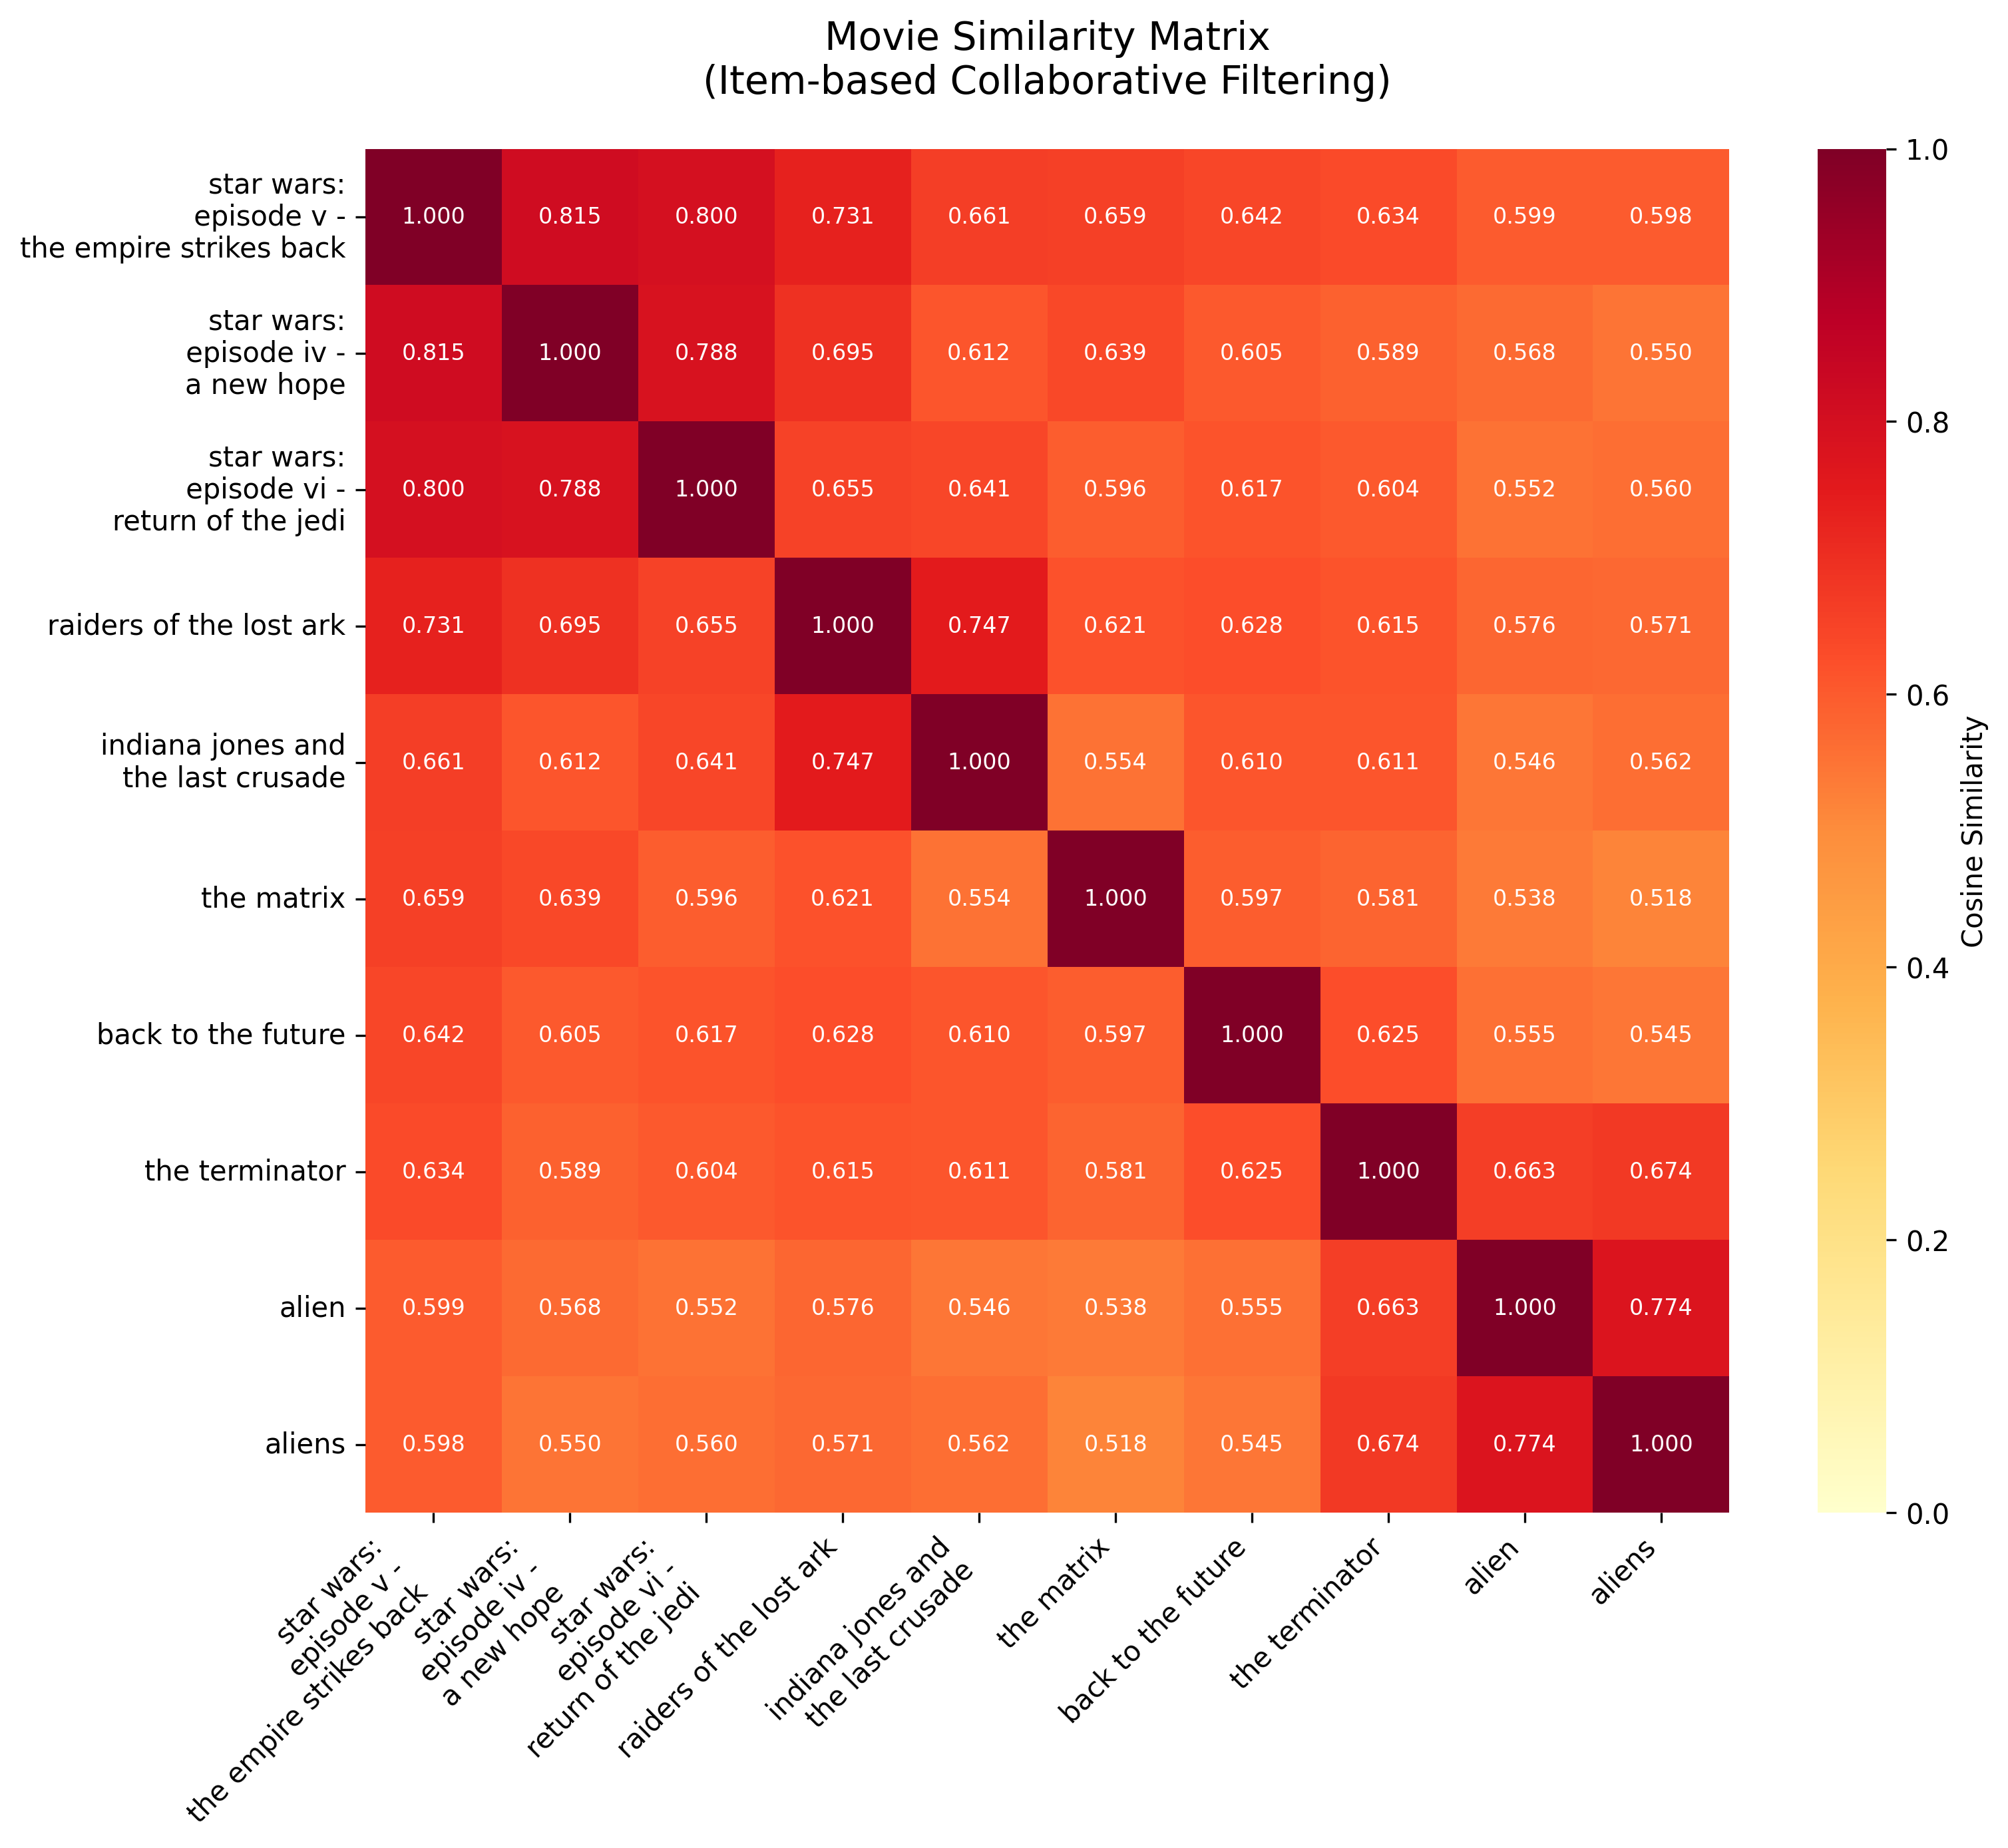

In [9]:
# Visualize collaborative filtering results
from pathlib import Path
from IPython.display import Image, display


# Show visualization images
image_files = list(analysis_dir.glob("*.png"))
if image_files:
    image_files = [img_file for img_file in image_files if img_file.name == "similarity_heatmap.png"]
    print(f"\n🖼️  Visualization plots ({len(image_files)} files):")
    for img_file in sorted(image_files):
        print(f"   {img_file.name}")
        display(Image(filename=str(img_file), width=800))